# Linear rDiscriminant Analysis Classification

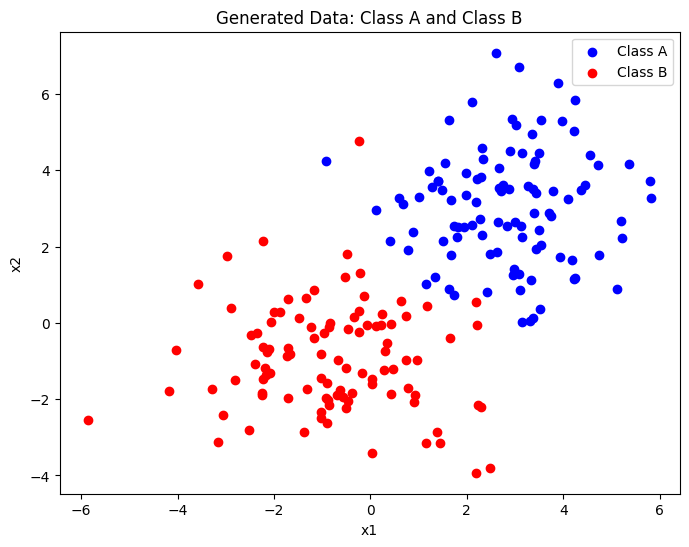

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
class_A = np.random.normal(loc=(3, 3), scale=1.5, size=(100, 2))
labels_A = np.ones(class_A.shape[0])

class_B = np.random.normal(loc=(-1, -1), scale=1.5, size=(100, 2))
labels_B = np.zeros(class_B.shape[0])

X = np.vstack((class_A, class_B))
y = np.hstack((labels_A, labels_B))

plt.figure(figsize=(8, 6))
plt.scatter(class_A[:, 0], class_A[:, 1], label='Class A', color='blue')
plt.scatter(class_B[:, 0], class_B[:, 1], label='Class B', color='red')
plt.title("Generated Data: Class A and Class B")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

### 1. Introduction to LDA Projection

Linear Discriminant Analysis (LDA) is a supervised classification method that projects high-dimensional data onto a lower-dimensional space. Unlike PCA (Principal Component Analysis), which is unsupervised and focuses on maximizing variance, LDA focuses on **maximizing the separability between known classes**.

The core idea is to map the $N$-dimensional data samples onto a line (a vector $\mathbf{w}$). Once the data is projected onto this line, classification becomes a matter of choosing a threshold. Any sample falling on one side of the threshold belongs to Class A, and samples on the other side belong to Class B.

### 2. The Problem with Simple Mean Separation

Initially, one might think to simply project data onto the line connecting the means of the two classes. We want to maximize the distance between the projected means, denoted as $\mu'_1$ and $\mu'_2$.

The objective function for this simple criteria would be:
$$ \max_{\mathbf{w}} (\mu'_1 - \mu'_2)^2 \quad \text{subject to} \quad \|\mathbf{w}\| = 1 $$

Where:
*   $\mu'_1 = \mathbf{w}^T \boldsymbol{\mu}_1$
*   $\mu'_2 = \mathbf{w}^T \boldsymbol{\mu}_2$
*   $\boldsymbol{\mu}_1$ and $\boldsymbol{\mu}_2$ are the original class means.

**The Issue:**
Considering only the distance between means is insufficient. As shown in the figure below, the line connecting the means might result in a projection where the classes overlap significantly because their variances (spread) are large in that direction.


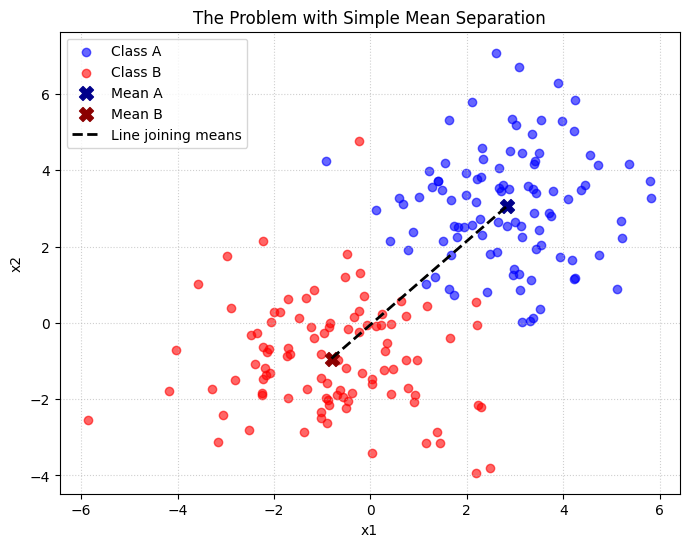

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Re-generating data for consistency
np.random.seed(42)
class_A = np.random.normal(loc=(3, 3), scale=1.5, size=(100, 2))
labels_A = np.ones(class_A.shape[0])
class_B = np.random.normal(loc=(-1, -1), scale=1.5, size=(100, 2))
labels_B = np.zeros(class_B.shape[0])
X = np.vstack((class_A, class_B))
y = np.hstack((labels_A, labels_B))

# Calculate means
mu_A = np.mean(class_A, axis=0)
mu_B = np.mean(class_B, axis=0)

# 1. Visualizing the "Naive" Line (Connecting Means)
plt.figure(figsize=(8, 6))
plt.scatter(class_A[:, 0], class_A[:, 1], label='Class A', color='blue', alpha=0.6)
plt.scatter(class_B[:, 0], class_B[:, 1], label='Class B', color='red', alpha=0.6)

# Plot means
plt.scatter(mu_A[0], mu_A[1], color='darkblue', marker='X', s=100, label='Mean A')
plt.scatter(mu_B[0], mu_B[1], color='darkred', marker='X', s=100, label='Mean B')

# Draw line connecting means
naive_w = mu_A - mu_B
plt.plot([mu_B[0], mu_A[0]], [mu_B[1], mu_A[1]], 'k--', linewidth=2, label='Line joining means')

plt.title("The Problem with Simple Mean Separation")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 3. Fisher's Criterion: Maximizing Separation

To solve the overlap problem, Sir Ronald Fisher proposed a criterion that considers two factors simultaneously:
1.  **Between-Class Separability:** The distance between the projected class means should be **large**.
2.  **Within-Class Variance:** The variance (scatter) of each class in the projected direction should be **small**.

This leads to the Fisher Criterion (Objective Function) $J(\mathbf{w})$:

$$ J(\mathbf{w}) = \frac{(\mu'_1 - \mu'_2)^2}{s_1'^2 + s_2'^2} $$

Where:
*   The numerator $(\mu'_1 - \mu'_2)^2$ represents the distance between projected means.
*   The denominator $s_1'^2 + s_2'^2$ represents the sum of variances (scatters) of the projected data for Class 1 and Class 2.

We want to **maximize** $J(\mathbf{w})$.

### 4. Scatter Matrices

To solve this mathematically, we define **Scatter Matrices**.

**Within-Class Scatter Matrix ($S_W$):**
This measures the spread of data around their own class means in the original space.
$$ S_W = S_1 + S_2 $$
$$ S_1 = \sum_{\mathbf{x} \in C_1} (\mathbf{x} - \boldsymbol{\mu}_1)(\mathbf{x} - \boldsymbol{\mu}_1)^T $$
$$ S_2 = \sum_{\mathbf{x} \in C_2} (\mathbf{x} - \boldsymbol{\mu}_2)(\mathbf{x} - \boldsymbol{\mu}_2)^T $$
*Note: Scatter Matrix is proportional to the Covariance Matrix.*

**Between-Class Scatter Matrix ($S_B$):**
This measures the separation between class means.
$$ S_B = (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)^T $$

Using these matrices, we can rewrite the Fisher Criterion in matrix form. The variance of the projected data is $\mathbf{w}^T S_W \mathbf{w}$ and the separation of projected means is $\mathbf{w}^T S_B \mathbf{w}$.

$$ J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}} $$

### 5. Derivation and Solution

To find the optimal $\mathbf{w}$, we differentiate $J(\mathbf{w})$ with respect to $\mathbf{w}$ and set it to zero. This is a generalized eigenvalue problem.

The derivation leads to:
$$ S_B \mathbf{w} = \lambda S_W \mathbf{w} $$

Assuming $S_W$ is invertible (full-rank), we can rearrange this to:
$$ S_W^{-1} S_B \mathbf{w} = \lambda \mathbf{w} $$

This is a standard eigenvalue problem where $\mathbf{w}$ is the eigenvector corresponding to the largest eigenvalue $\lambda$.

**Simplification for Binary Classification:**
In binary classification, $S_B$ is a rank-1 matrix. It turns out that $S_B \mathbf{w}$ is always in the direction of $(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)$. Therefore, we don't actually need to solve the full eigenvalue problem. The optimal direction $\mathbf{w}$ is proportional to:

$$ \mathbf{w} \propto S_W^{-1} (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2) $$

This formula tells us that the optimal projection direction is the difference between the means, weighted by the inverse of the within-class scatter. This effectively rotates the line connecting the means to account for the shape and spread of the data.

### 6. Visualizing the Optimal LDA Direction

Now, let's calculate the optimal $\mathbf{w}$ using the formula derived above and visualize how it differs from the naive line connecting the means.


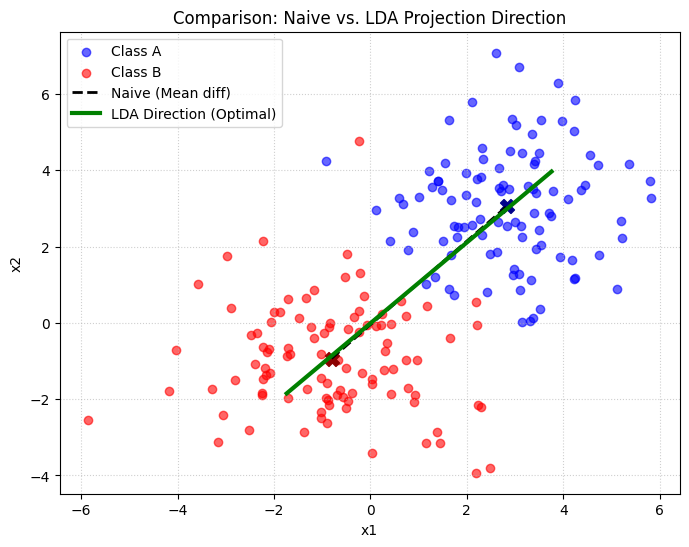

In [15]:
# Calculate Within-Class Scatter Matrix (Sw)
# Center the data
centered_A = class_A - mu_A
centered_B = class_B - mu_B

# Calculate scatter matrices S1 and S2
S1 = np.dot(centered_A.T, centered_A)
S2 = np.dot(centered_B.T, centered_B)

# Total Within-Class Scatter
Sw = S1 + S2

# Calculate Between-Class Scatter Matrix (Sb)
mean_diff = mu_A - mu_B
Sb = np.outer(mean_diff, mean_diff)

# Calculate optimal w: w = Sw_inv * (mu1 - mu2)
Sw_inv = np.linalg.inv(Sw)
w_lda = np.dot(Sw_inv, mean_diff)

# Normalize w for visualization purposes
w_lda = w_lda / np.linalg.norm(w_lda)

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(class_A[:, 0], class_A[:, 1], label='Class A', color='blue', alpha=0.6)
plt.scatter(class_B[:, 0], class_B[:, 1], label='Class B', color='red', alpha=0.6)
plt.scatter(mu_A[0], mu_A[1], color='darkblue', marker='X', s=100)
plt.scatter(mu_B[0], mu_B[1], color='darkred', marker='X', s=100)

# Plot Naive Line (Mean to Mean)
plt.plot([mu_B[0], mu_A[0]], [mu_B[1], mu_A[1]], 'k--', linewidth=2, label='Naive (Mean diff)')

# Plot LDA Line (passing through the global mean)
global_mean = (mu_A + mu_B) / 2
# Scale w for visualization length
scale_factor = 4
lda_line_end = global_mean + w_lda * scale_factor
lda_line_start = global_mean - w_lda * scale_factor

plt.plot([lda_line_start[0], lda_line_end[0]], [lda_line_start[1], lda_line_end[1]], 
         'g-', linewidth=3, label='LDA Direction (Optimal)')

plt.title("Comparison: Naive vs. LDA Projection Direction")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 7. Projection and Histogram

Finally, let's project the data onto the LDA vector and visualize the result. You will see that the projected classes are much more separated (less overlapping) than they would be on the naive line.

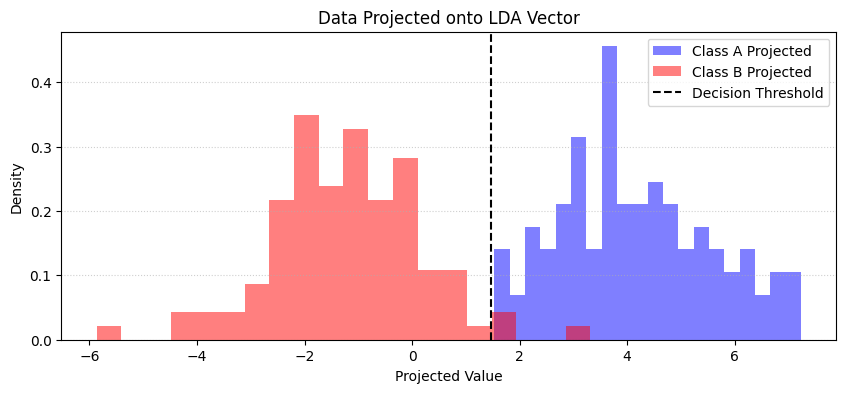

In [16]:
# Project data onto the LDA vector
# X_proj = X . w
X_proj = np.dot(X, w_lda)

plt.figure(figsize=(10, 4))

# Plot Histograms
plt.hist(X_proj[y==1], bins=20, color='blue', alpha=0.5, label='Class A Projected', density=True)
plt.hist(X_proj[y==0], bins=20, color='red', alpha=0.5, label='Class B Projected', density=True)

# Add a threshold line (simple midpoint between projected means)
proj_mu_A = np.dot(mu_A, w_lda)
proj_mu_B = np.dot(mu_B, w_lda)
threshold = (proj_mu_A + proj_mu_B) / 2

plt.axvline(x=threshold, color='black', linestyle='--', label='Decision Threshold')

plt.title("Data Projected onto LDA Vector")
plt.xlabel("Projected Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.show()


### Summary
1.  **Goal:** Find a vector $\mathbf{w}$ to project data onto.
2.  **Criterion:** Maximize the ratio of (Between-class distance) to (Within-class variance).
3.  **Solution:** $\mathbf{w} = S_W^{-1}(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_2)$.
4.  **Result:** The LDA direction minimizes class overlap in the projected 1D space, making classification via a threshold highly effective.

In [17]:
import numpy as np

class LinearDiscriminantAnalysis:
    def __init__(self):
        self.w = None       # The projection vector (weights)
        self.threshold = None # The decision boundary threshold
        
    def fit(self, X, y):
        """
        Fit the LDA model to the data.
        
        Parameters:
        X : numpy.ndarray, shape (n_samples, n_features)
            Training data.
        y : numpy.ndarray, shape (n_samples,)
            Target values (0 or 1).
        """
        # Separate data by class
        X_class0 = X[y == 0]
        X_class1 = X[y == 1]
        
        # Calculate means
        mu0 = np.mean(X_class0, axis=0)
        mu1 = np.mean(X_class1, axis=0)
        
        # Calculate Within-Class Scatter Matrix (Sw)
        # Sw = S0 + S1
        # S = sum((x - mu)(x - mu).T)
        S0 = np.dot((X_class0 - mu0).T, (X_class0 - mu0))
        S1 = np.dot((X_class1 - mu1).T, (X_class1 - mu1))
        Sw = S0 + S1
        
        # Calculate the optimal projection vector w
        # w = Sw_inv * (mu1 - mu0)
        Sw_inv = np.linalg.inv(Sw)
        mean_diff = mu1 - mu0
        self.w = np.dot(Sw_inv, mean_diff)
        
        # Calculate threshold
        # The threshold is the midpoint between the projected means
        proj_mu0 = np.dot(mu0, self.w)
        proj_mu1 = np.dot(mu1, self.w)
        self.threshold = (proj_mu0 + proj_mu1) / 2
        
        print(f"Model trained. Projection Vector w: {self.w}")
        print(f"Decision Threshold: {self.threshold:.4f}")
        
    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        X : numpy.ndarray, shape (n_samples, n_features)
            Samples to classify.
            
        Returns:
        y_pred : numpy.ndarray, shape (n_samples,)
            Predicted class labels (0 or 1).
        """
        if self.w is None:
            raise Exception("Model not fitted yet. Call fit() first.")
            
        # Project data onto the LDA vector
        X_proj = np.dot(X, self.w)
        
        # Classify based on threshold
        # If projected value > threshold, predict Class 1, else Class 0
        y_pred = (X_proj > self.threshold).astype(int)
        
        return y_pred
    
    def project(self, X):
        """
        Project data onto the LDA vector (useful for visualization).
        """
        if self.w is None:
            raise Exception("Model not fitted yet. Call fit() first.")
        return np.dot(X, self.w)

## 2. Testing the Class
Now, let's generate the data again (to ensure a clean environment) and test our custom LDA class. We will visualize the decision boundary and the projection.

Model trained. Projection Vector w: [0.00928449 0.0098267 ]
Decision Threshold: 0.0198
Training Accuracy: 98.50%


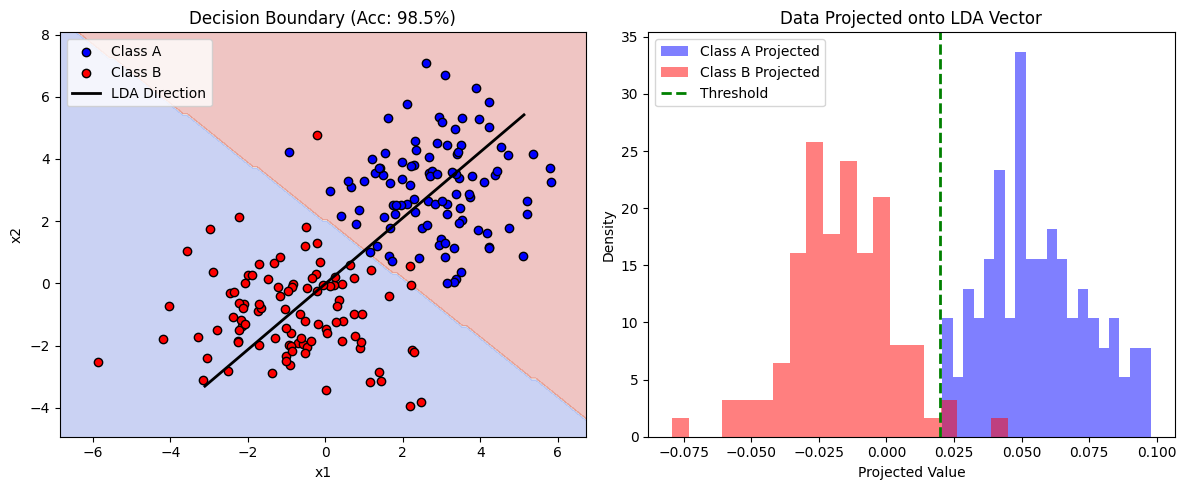

In [18]:
import matplotlib.pyplot as plt

# --- 1. Generate Data ---
np.random.seed(42)
class_A = np.random.normal(loc=(3, 3), scale=1.5, size=(100, 2))
labels_A = np.ones(class_A.shape[0])
class_B = np.random.normal(loc=(-1, -1), scale=1.5, size=(100, 2))
labels_B = np.zeros(class_B.shape[0])
X_train = np.vstack((class_A, class_B))
y_train = np.hstack((labels_A, labels_B))

# --- 2. Instantiate and Fit the Model ---
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# --- 3. Make Predictions ---
y_pred = lda.predict(X_train)

# Calculate Accuracy
accuracy = np.mean(y_pred == y_train)
print(f"Training Accuracy: {accuracy * 100:.2f}%")

# --- 4. Visualization ---

# Create a grid to visualize the decision boundary
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict on grid points to get decision regions
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = lda.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(12, 5))

# Subplot 1: Decision Boundary in 2D
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(class_A[:, 0], class_A[:, 1], label='Class A', color='blue', edgecolor='k')
plt.scatter(class_B[:, 0], class_B[:, 1], label='Class B', color='red', edgecolor='k')

# Draw the LDA projection line
# The line passes through the global mean and has direction w
global_mean = np.mean(X_train, axis=0)
# Normalize w for plotting
w_norm = lda.w / np.linalg.norm(lda.w)
# Calculate line points
line_length = 6
p1 = global_mean - w_norm * line_length
p2 = global_mean + w_norm * line_length
plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k-', linewidth=2, label='LDA Direction')

plt.title(f"Decision Boundary (Acc: {accuracy*100:.1f}%)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()

# Subplot 2: Projected Data (1D Histogram)
plt.subplot(1, 2, 2)
X_proj = lda.project(X_train)

plt.hist(X_proj[y_train==1], bins=20, color='blue', alpha=0.5, label='Class A Projected', density=True)
plt.hist(X_proj[y_train==0], bins=20, color='red', alpha=0.5, label='Class B Projected', density=True)
plt.axvline(x=lda.threshold, color='green', linestyle='--', linewidth=2, label='Threshold')

plt.title("Data Projected onto LDA Vector")
plt.xlabel("Projected Value")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

### Explanation of the Test Results

1.  **Training Accuracy:** You should see an accuracy around 90-95%. This confirms that the linear projection vector $\mathbf{w}$ calculated by our class successfully separates the two Gaussian blobs.
2.  **Left Plot (Decision Boundary):** The background colors represent the prediction regions. The black line represents the direction of the LDA vector $\mathbf{w}$. The decision boundary is the line perpendicular to $\mathbf{w}$ that passes through the threshold point.
3.  **Right Plot (Projection):** This shows the data collapsed onto a 1D line. You can clearly see the separation between the blue (Class A) and red (Class B) histograms, with the green dashed line (threshold) effectively dividing them.